<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/Qatar_policy_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
dff=pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")


In [ ]:
dff.tail()

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
143,United Arab Emirates,2022,511.403,5.291226,10.289,3054795,90000,100.93,0.272294,2.873,...,0,0,0,0,0,1,1,1,1,1
144,United Arab Emirates,2023,522.622,1.626708,10.679,3151670,105000,82.49,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
145,United Arab Emirates,2024,552.325,1.663365,11.294,3248545,115000,80.52,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
146,United Arab Emirates,2025,571.643,1.250865,11.380,3405095,115000,69.14,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
147,United Arab Emirates,2026,621.546,1.250865,11.465,3497584,115000,69.14,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1


Qatar first policy with all three method

Policy : Kafala_Reform
Policy Year : 2020

DESCRIPTIVE ANALYSIS
----------------------------------------
Median Before : 732643.33
Median After  : 735692.0
Difference    : 3048.67


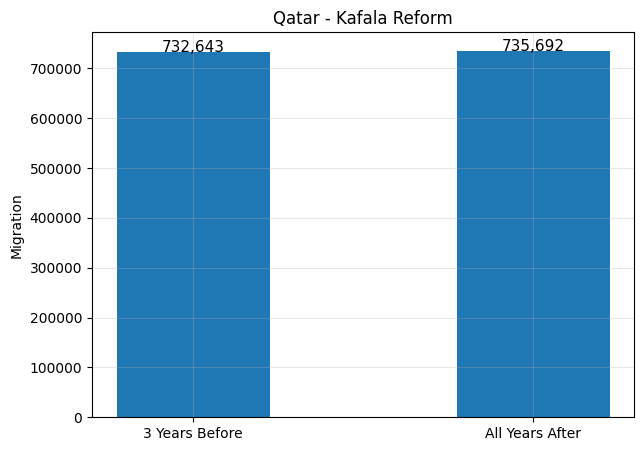


Variance Explained
[0.726  0.2004 0.0638]

PCA MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     252.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.70e-24
Time:                        14:06:10   Log-Likelihood:                -449.16
No. Observations:                  37   AIC:                             912.3
Df Residuals:                      30   BIC:                             923.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

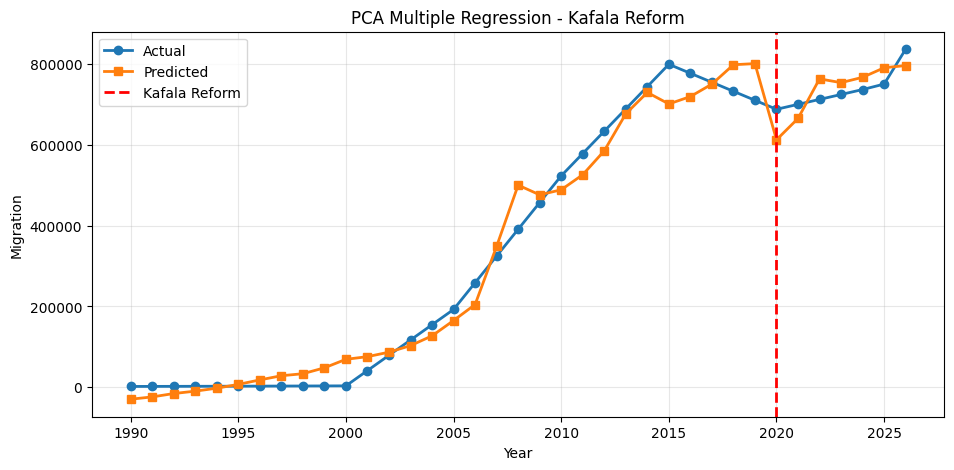

ENHANCED INTERRUPTED TIME SERIES
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     496.4
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.91e-28
Time:                        14:06:10   Log-Likelihood:                -446.22
No. Observations:                  37   AIC:                             910.4
Df Residuals:                      28   BIC:                             924.9
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept    

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


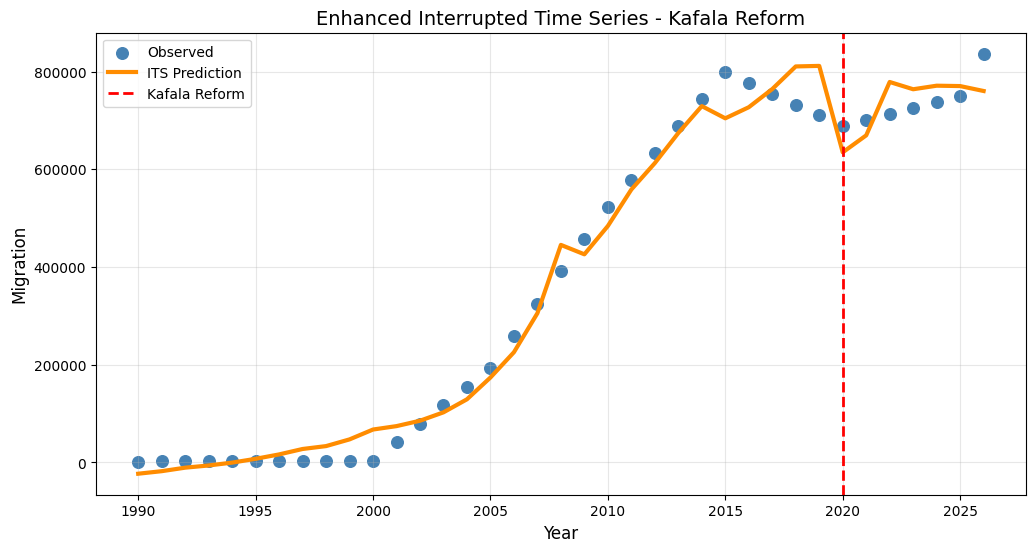

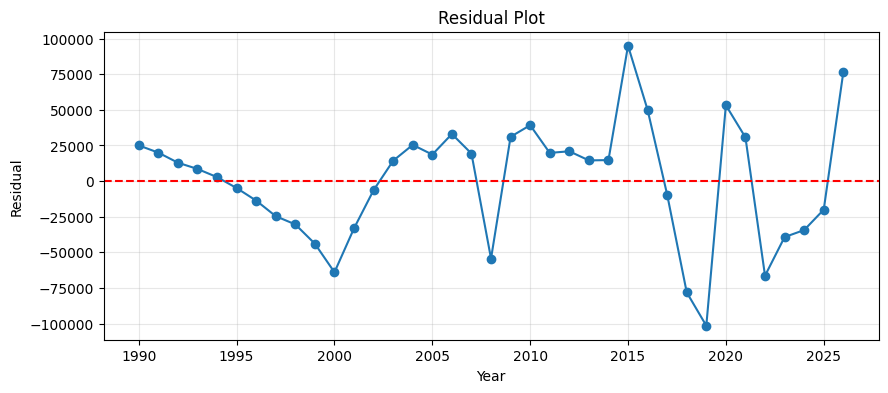


Durbin-Watson : 1.21


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

qatar = df[df["Country"]=="Qatar"].copy()

policy = "Kafala_Reform"

policy_year = qatar.loc[
    qatar[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = qatar[
    (qatar["Year"] >= policy_year-3) &
    (qatar["Year"] < policy_year)
]

after = qatar[
    qatar["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

before_median = before["Migration"].mean()
after_median = after["Migration"].mean()

print("Median Before :", round(before_median,2))
print("Median After  :", round(after_median,2))
print("Difference    :", round(after_median-before_median,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","All Years After"],
    [before_median,after_median],
    width=0.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Qatar - Kafala Reform")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : PCA + MULTIPLE LINEAR REGRESSION
# ======================================================

qatar["COVID"] = (qatar["Year"]>=2020).astype(int)

qatar["Year_Index"] = qatar["Year"]-qatar["Year"].min()

features = [

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X = qatar[features]

X = X.fillna(X.median())

y = qatar["Migration"]

# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(pca.explained_variance_ratio_,4))

# Create PCA dataframe

pca_columns = []

for i in range(X_pca.shape[1]):
    pca_columns.append(f"PC{i+1}")

pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=qatar.index
)

# Merge with policy variables

reg_data = pd.concat(

[
pca_df,
qatar[["Migration",
        "COVID",
        "Year_Index",
        "Kafala_Reform"]]
],

axis=1

)

formula = "Migration ~ "

formula += " + ".join(pca_columns)

formula += " + COVID + Year_Index + Kafala_Reform"

model = smf.ols(

formula,

data=reg_data

).fit()

print("\nPCA MULTIPLE REGRESSION")

print(model.summary())

reg_data["Prediction"] = model.predict(reg_data)

print("\nRegression Performance")

print("----------------------------")

print("R² :", round(

r2_score(
reg_data["Migration"],
reg_data["Prediction"]),4))

print("RMSE :", round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)),2))

plt.figure(figsize=(11,5))

plt.plot(

qatar["Year"],
reg_data["Migration"],
marker='o',
linewidth=2,
label="Actual"

)

plt.plot(

qatar["Year"],
reg_data["Prediction"],
marker='s',
linewidth=2,
label="Predicted"

)

plt.axvline(

policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Kafala Reform"

)

plt.title("PCA Multiple Regression - Kafala Reform")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 3 : ENHANCED INTERRUPTED TIME SERIES
# ======================================================

qatar = qatar.sort_values("Year").copy()

# -------------------------------
# Center time around policy year
# -------------------------------

qatar["Time"] = qatar["Year"] - policy_year

# Policy Indicator

qatar["Policy"] = (qatar["Year"] >= policy_year).astype(int)

# Time after intervention

qatar["Time_After"] = qatar["Time"].clip(lower=0)

# Interaction Term

qatar["Policy_Time"] = (
    qatar["Policy"] *
    qatar["Time_After"]
)

# COVID

qatar["COVID"] = (qatar["Year"]>=2020).astype(int)

# ---------------------------------
# Enhanced ITS Model
# ---------------------------------

its = smf.ols(

"""
Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=qatar

).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":2}
)

print("="*60)
print("ENHANCED INTERRUPTED TIME SERIES")
print("="*60)

print(its.summary())

# ---------------------------------
# Prediction
# ---------------------------------

qatar["ITS_Prediction"] = its.predict(qatar)

# ---------------------------------
# Performance
# ---------------------------------

print("\nITS PERFORMANCE")
print("-"*30)

print("R² :",
      round(
          r2_score(
              qatar["Migration"],
              qatar["ITS_Prediction"]
          ),4)
)

print("RMSE :",
      round(
          np.sqrt(
              mean_squared_error(
                  qatar["Migration"],
                  qatar["ITS_Prediction"]
              )
          ),2)
)

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(12,6))

plt.scatter(
    qatar["Year"],
    qatar["Migration"],
    color="steelblue",
    s=70,
    label="Observed"
)

plt.plot(
    qatar["Year"],
    qatar["ITS_Prediction"],
    color="darkorange",
    linewidth=3,
    label="ITS Prediction"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Kafala Reform"
)

plt.xlabel("Year",fontsize=12)

plt.ylabel("Migration",fontsize=12)

plt.title(
    "Enhanced Interrupted Time Series - Kafala Reform",
    fontsize=14
)

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ---------------------------------
# Residual Diagnostics
# ---------------------------------

qatar["Residuals"] = (
    qatar["Migration"] -
    qatar["ITS_Prediction"]
)

plt.figure(figsize=(10,4))

plt.plot(
    qatar["Year"],
    qatar["Residuals"],
    marker="o"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ---------------------------------
# Durbin-Watson Test
# ---------------------------------

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))


Qatar second policy with all methods

Policy : Minimum_Wage_Law
Policy Year : 2021

DESCRIPTIVE ANALYSIS
----------------------------
Median Before : 710360.0
Median After  : 743627.83
Difference    : 33267.83


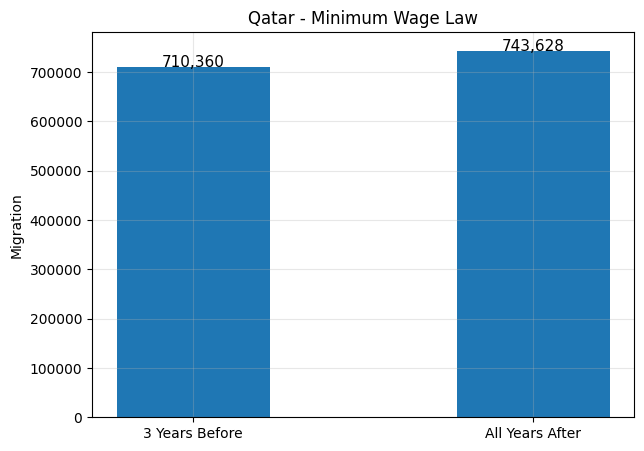


Variance Explained
[0.726  0.2004 0.0638]

PCA MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     278.5
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.55e-25
Time:                        14:06:13   Log-Likelihood:                -447.41
No. Observations:                  37   AIC:                             908.8
Df Residuals:                      30   BIC:                             920.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

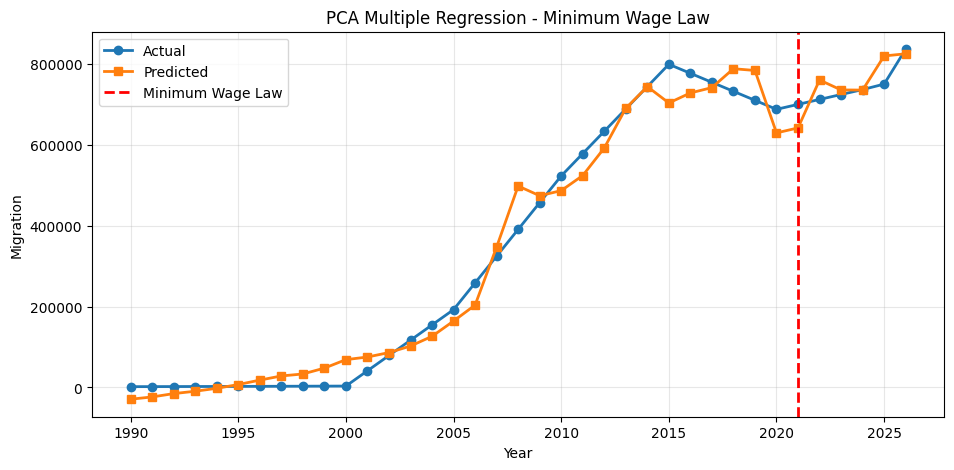


ENHANCED ITS
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     185.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.47e-22
Time:                        14:06:13   Log-Likelihood:                -442.16
No. Observations:                  37   AIC:                             904.3
Df Residuals:                      27   BIC:                             920.4
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -6.434e+04   1.98e

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


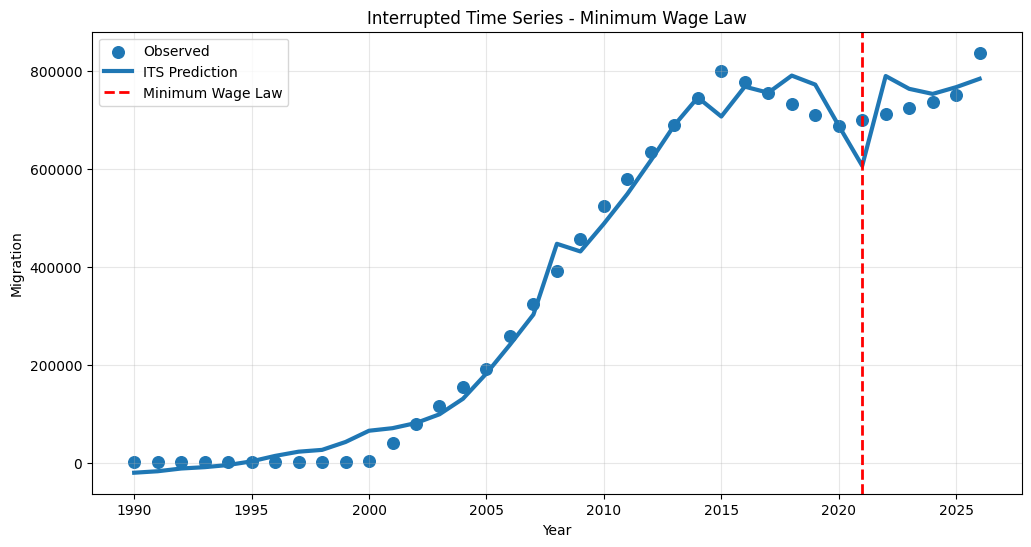

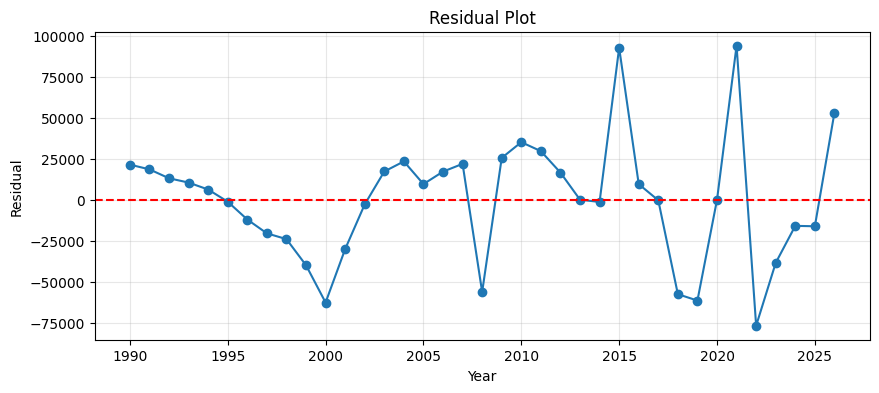


Durbin-Watson : 1.63


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

qatar = df[df["Country"]=="Qatar"].copy()

policy = "Minimum_Wage_Law"

policy_year = qatar.loc[
    qatar[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :",policy)
print("Policy Year :",policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = qatar[
    (qatar["Year"]>=policy_year-3) &
    (qatar["Year"]<policy_year)
]

after = qatar[
    qatar["Year"]>=policy_year
]

before_median = before["Migration"].mean()
after_median = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("----------------------------")

print("Median Before :",round(before_median,2))
print("Median After  :",round(after_median,2))
print("Difference    :",round(after_median-before_median,2))

plt.figure(figsize=(7,5))

bars=plt.bar(
    ["3 Years Before","All Years After"],
    [before_median,after_median],
    width=.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Qatar - Minimum Wage Law")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : PCA + MULTIPLE REGRESSION
# ======================================================

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

qatar["Year_Index"]=qatar["Year"]-qatar["Year"].min()

features=[

"Population",
"GDP",
"Inflation",
"Oil_Price",
"Exchange_Rate",
"Unemployment"

]

X=qatar[features]

X=X.fillna(X.median())

y=qatar["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(pca.explained_variance_ratio_,4))

pc_names=[]

for i in range(X_pca.shape[1]):
    pc_names.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=pc_names,
    index=qatar.index
)

reg_data=pd.concat(

[
pca_df,

qatar[[
"Migration",
"COVID",
"Year_Index",
"Minimum_Wage_Law"
]]

],

axis=1

)

formula="Migration ~ "

formula+=" + ".join(pc_names)

formula+=" + COVID + Year_Index + Minimum_Wage_Law"

model=smf.ols(

formula,

data=reg_data

).fit()

print("\nPCA MULTIPLE REGRESSION")

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nRegression Performance")

print("----------------------------")

print("R² :",round(

r2_score(
reg_data["Migration"],
reg_data["Prediction"]),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"])),2))

plt.figure(figsize=(11,5))

plt.plot(
qatar["Year"],
reg_data["Migration"],
marker='o',
linewidth=2,
label="Actual"
)

plt.plot(
qatar["Year"],
reg_data["Prediction"],
marker='s',
linewidth=2,
label="Predicted"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Minimum Wage Law"
)

plt.title("PCA Multiple Regression - Minimum Wage Law")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 3 : ENHANCED INTERRUPTED TIME SERIES
# ======================================================

qatar=qatar.sort_values("Year").copy()

qatar["Time"]=qatar["Year"]-policy_year

qatar["Policy"]=(qatar["Year"]>=policy_year).astype(int)

qatar["Time_After"]=qatar["Time"].clip(lower=0)

qatar["Policy_Time"]=qatar["Policy"]*qatar["Time_After"]

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

its=smf.ols(

"""
Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=qatar

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("\nENHANCED ITS")

print(its.summary())

qatar["ITS_Prediction"]=its.predict(qatar)

print("\nITS Performance")

print("----------------------------")

print("R² :",round(

r2_score(

qatar["Migration"],
qatar["ITS_Prediction"]

),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(

qatar["Migration"],
qatar["ITS_Prediction"]

)),2))

plt.figure(figsize=(12,6))

plt.scatter(
qatar["Year"],
qatar["Migration"],
s=70,
label="Observed"
)

plt.plot(
qatar["Year"],
qatar["ITS_Prediction"],
linewidth=3,
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Minimum Wage Law"
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Interrupted Time Series - Minimum Wage Law")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 4 : RESIDUAL ANALYSIS
# ======================================================

qatar["Residuals"]=qatar["Migration"]-qatar["ITS_Prediction"]

plt.figure(figsize=(10,4))

plt.plot(
qatar["Year"],
qatar["Residuals"],
marker="o"
)

plt.axhline(
0,
color="red",
linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# STEP 5 : DURBIN-WATSON
# ======================================================

dw=durbin_watson(its.resid)

print("\nDurbin-Watson :",round(dw,3))

Qatar third policy with all methods

Policy : Exit_Permit_Removal
Policy Year : 2018

DESCRIPTIVE ANALYSIS
----------------------------
Median Before : 777210.0
Median After  : 732538.56
Difference    : -44671.44


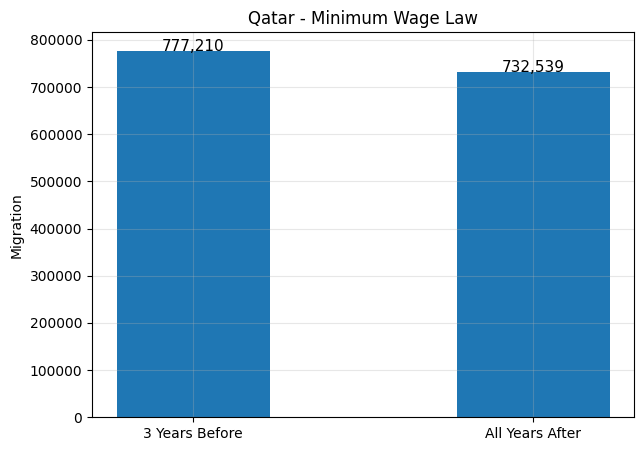


Variance Explained
[0.726  0.2004 0.0638]

PCA MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     278.5
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.55e-25
Time:                        14:43:42   Log-Likelihood:                -447.41
No. Observations:                  37   AIC:                             908.8
Df Residuals:                      30   BIC:                             920.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

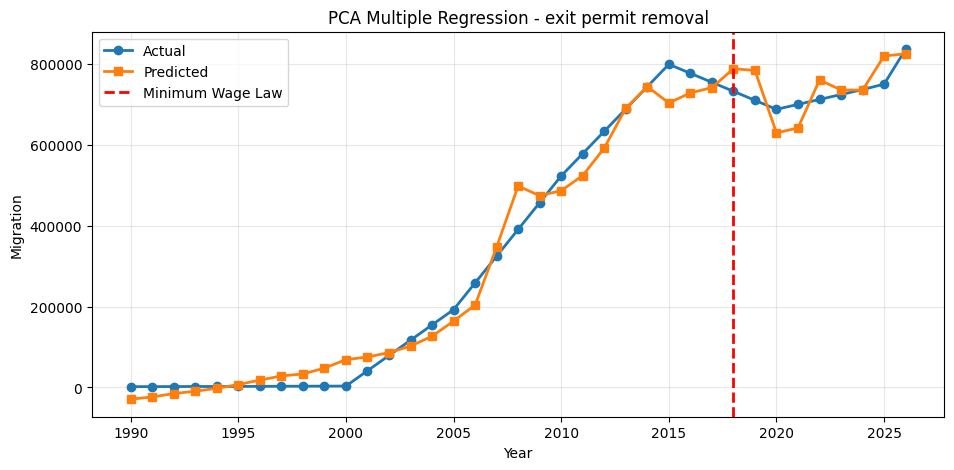


ENHANCED ITS
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     8248.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.41e-44
Time:                        14:43:42   Log-Likelihood:                -435.38
No. Observations:                  37   AIC:                             890.8
Df Residuals:                      27   BIC:                             906.9
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5596.7637    1.4e

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


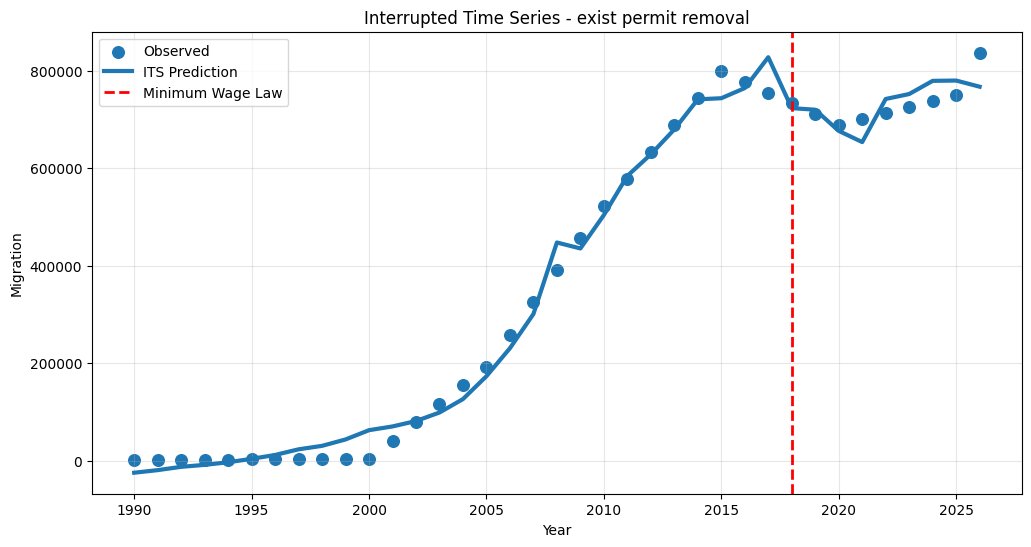

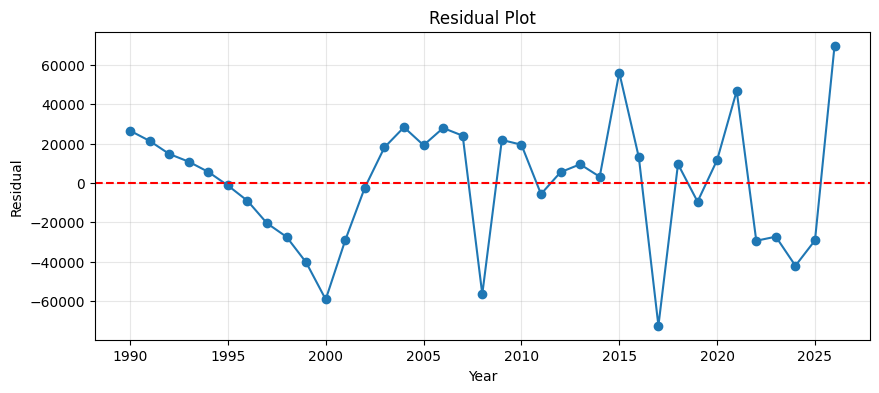


Durbin-Watson : 1.484


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

qatar = df[df["Country"]=="Qatar"].copy()

policy = "Exit_Permit_Removal"

policy_year = qatar.loc[
    qatar[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :",policy)
print("Policy Year :",policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = qatar[
    (qatar["Year"]>=policy_year-3) &
    (qatar["Year"]<policy_year)
]

after = qatar[
    qatar["Year"]>=policy_year
]

before_median = before["Migration"].mean()
after_median = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("----------------------------")

print("Median Before :",round(before_median,2))
print("Median After  :",round(after_median,2))
print("Difference    :",round(after_median-before_median,2))

plt.figure(figsize=(7,5))

bars=plt.bar(
    ["3 Years Before","All Years After"],
    [before_median,after_median],
    width=.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Qatar - Minimum Wage Law")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : PCA + MULTIPLE REGRESSION
# ======================================================

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

qatar["Year_Index"]=qatar["Year"]-qatar["Year"].min()

features=[

"Population",
"GDP",
"Inflation",
"Oil_Price",
"Exchange_Rate",
"Unemployment"

]

X=qatar[features]

X=X.fillna(X.median())

y=qatar["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(pca.explained_variance_ratio_,4))

pc_names=[]

for i in range(X_pca.shape[1]):
    pc_names.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=pc_names,
    index=qatar.index
)

reg_data=pd.concat(

[
pca_df,

qatar[[
"Migration",
"COVID",
"Year_Index",
"Minimum_Wage_Law"
]]

],

axis=1

)

formula="Migration ~ "

formula+=" + ".join(pc_names)

formula+=" + COVID + Year_Index + Minimum_Wage_Law"

model=smf.ols(

formula,

data=reg_data

).fit()

print("\nPCA MULTIPLE REGRESSION")

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nRegression Performance")

print("----------------------------")

print("R² :",round(

r2_score(
reg_data["Migration"],
reg_data["Prediction"]),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"])),2))

plt.figure(figsize=(11,5))

plt.plot(
qatar["Year"],
reg_data["Migration"],
marker='o',
linewidth=2,
label="Actual"
)

plt.plot(
qatar["Year"],
reg_data["Prediction"],
marker='s',
linewidth=2,
label="Predicted"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Minimum Wage Law"
)

plt.title("PCA Multiple Regression - exit permit removal")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 3 : ENHANCED INTERRUPTED TIME SERIES
# ======================================================

qatar=qatar.sort_values("Year").copy()

qatar["Time"]=qatar["Year"]-policy_year

qatar["Policy"]=(qatar["Year"]>=policy_year).astype(int)

qatar["Time_After"]=qatar["Time"].clip(lower=0)

qatar["Policy_Time"]=qatar["Policy"]*qatar["Time_After"]

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

its=smf.ols(

"""
Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=qatar

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("\nENHANCED ITS")

print(its.summary())

qatar["ITS_Prediction"]=its.predict(qatar)

print("\nITS Performance")

print("----------------------------")

print("R² :",round(

r2_score(

qatar["Migration"],
qatar["ITS_Prediction"]

),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(

qatar["Migration"],
qatar["ITS_Prediction"]

)),2))

plt.figure(figsize=(12,6))

plt.scatter(
qatar["Year"],
qatar["Migration"],
s=70,
label="Observed"
)

plt.plot(
qatar["Year"],
qatar["ITS_Prediction"],
linewidth=3,
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Minimum Wage Law"
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Interrupted Time Series - exist permit removal")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 4 : RESIDUAL ANALYSIS
# ======================================================

qatar["Residuals"]=qatar["Migration"]-qatar["ITS_Prediction"]

plt.figure(figsize=(10,4))

plt.plot(
qatar["Year"],
qatar["Residuals"],
marker="o"
)

plt.axhline(
0,
color="red",
linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# STEP 5 : DURBIN-WATSON
# ======================================================

dw=durbin_watson(its.resid)

print("\nDurbin-Watson :",round(dw,3))

Qatar fourth policy with all methods

Policy : World_Cup_Infrastructure_Program
Policy Year : 2010

DESCRIPTIVE ANALYSIS
----------------------------------------
Median Before : 390982.33
Median After  : 711375.18
Difference    : 320392.84


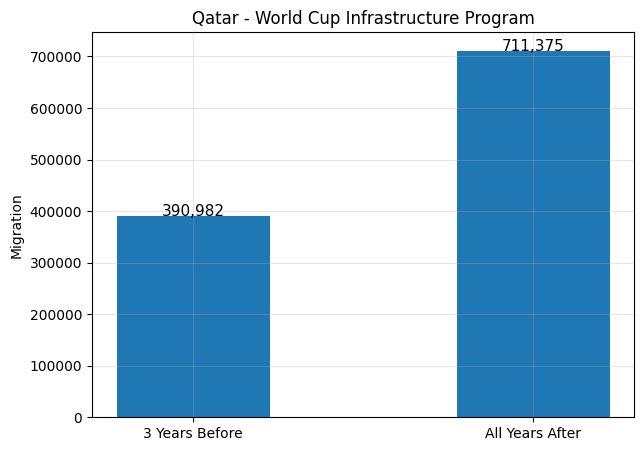


Variance Explained
[0.726  0.2004 0.0638]

PCA MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     303.8
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.82e-25
Time:                        14:06:35   Log-Likelihood:                -445.82
No. Observations:                  37   AIC:                             905.6
Df Residuals:                      30   BIC:                             916.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

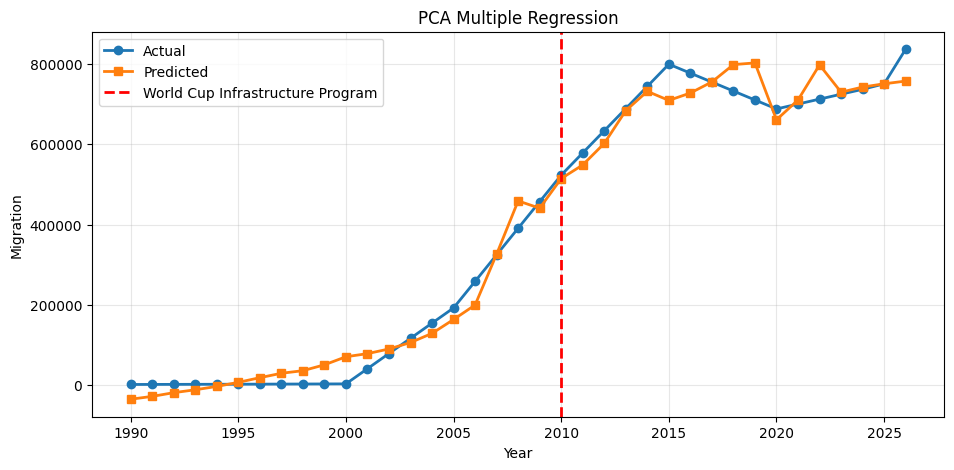


ENHANCED INTERRUPTED TIME SERIES
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1081.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.91e-32
Time:                        14:06:36   Log-Likelihood:                -437.91
No. Observations:                  37   AIC:                             895.8
Df Residuals:                      27   BIC:                             911.9
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


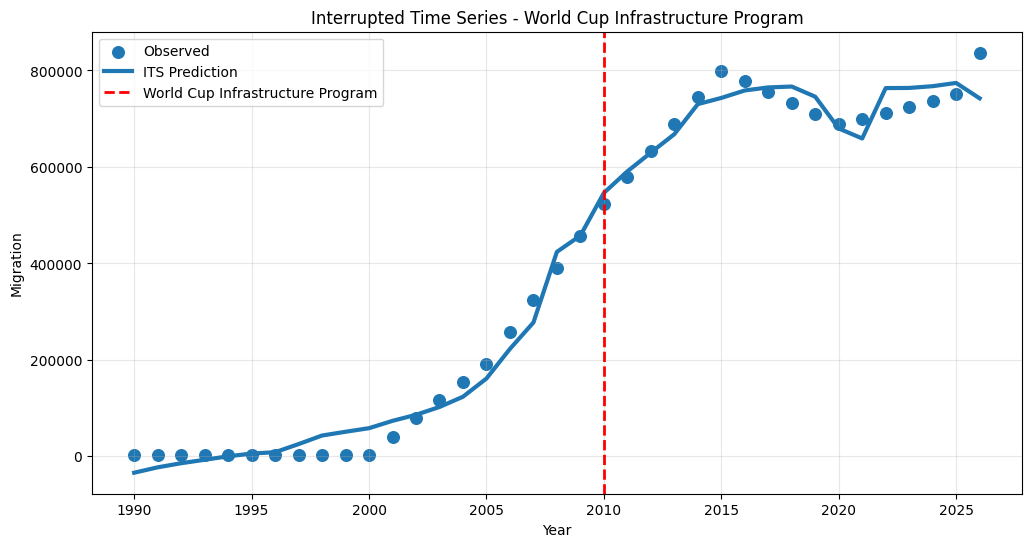

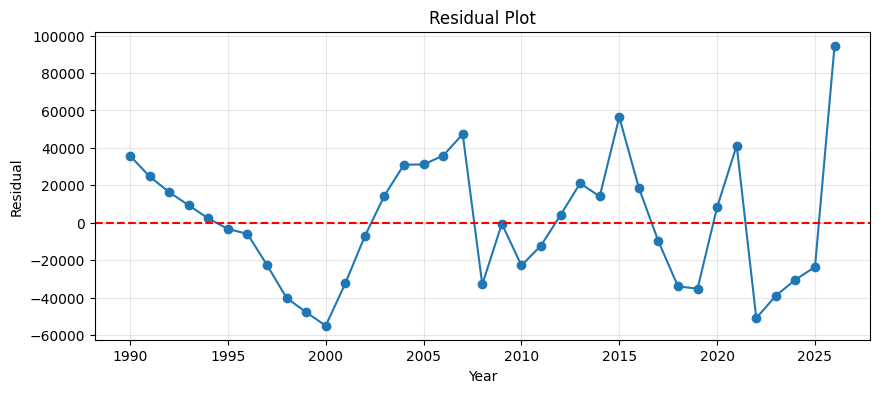


Durbin-Watson Statistic : 1.021
Positive autocorrelation detected.

Analysis Completed Successfully.


In [ ]:
# ============================================================
# QATAR - WORLD CUP INFRASTRUCTURE PROGRAM ANALYSIS
# Descriptive Analysis + PCA Regression + Interrupted Time Series
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")
# If using uploaded file locally:
# df = pd.read_excel("/mnt/data/Final_Master_Dataset_Cleaned(3).xlsx")

# ======================================================
# FILTER QATAR DATA
# ======================================================

qatar = df[df["Country"] == "Qatar"].copy()

policy = "World_Cup_Infrastructure_Program"

policy_year = qatar.loc[
    qatar[policy] == 1,
    "Year"
].min()

print("=" * 60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("=" * 60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = qatar[
    (qatar["Year"] >= policy_year - 3) &
    (qatar["Year"] < policy_year)
]

after = qatar[
    qatar["Year"] >= policy_year
]

before_median = before["Migration"].mean()
after_median = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("-" * 40)
print("Median Before :", round(before_median, 2))
print("Median After  :", round(after_median, 2))
print("Difference    :", round(after_median - before_median, 2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before", "All Years After"],
    [before_median, after_median],
    width=0.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Qatar - World Cup Infrastructure Program")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : PCA + MULTIPLE REGRESSION
# ======================================================

qatar["COVID"] = (qatar["Year"] >= 2020).astype(int)
qatar["Year_Index"] = qatar["Year"] - qatar["Year"].min()

features = [
    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]

X = qatar[features]
X = X.fillna(X.median())

y = qatar["Migration"]

# Standardize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("\nVariance Explained")
print(np.round(pca.explained_variance_ratio_,4))

pc_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]

pca_df = pd.DataFrame(
    X_pca,
    columns=pc_names,
    index=qatar.index
)

# Regression Data

reg_data = pd.concat(
    [
        pca_df,
        qatar[
            [
                "Migration",
                "COVID",
                "Year_Index",
                policy
            ]
        ]
    ],
    axis=1
)

# Regression Formula

formula = (
    "Migration ~ "
    + " + ".join(pc_names)
    + f" + COVID + Year_Index + {policy}"
)

model = smf.ols(
    formula,
    data=reg_data
).fit()

print("\nPCA MULTIPLE REGRESSION")
print(model.summary())

# Prediction

reg_data["Prediction"] = model.predict(reg_data)

print("\nRegression Performance")
print("-"*40)

print("R² :", round(
    r2_score(
        reg_data["Migration"],
        reg_data["Prediction"]
    ),
4))

print("RMSE :", round(
    np.sqrt(
        mean_squared_error(
            reg_data["Migration"],
            reg_data["Prediction"]
        )
    ),
2))

# Plot

plt.figure(figsize=(11,5))

plt.plot(
    qatar["Year"],
    reg_data["Migration"],
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    qatar["Year"],
    reg_data["Prediction"],
    marker='s',
    linewidth=2,
    label="Predicted"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="World Cup Infrastructure Program"
)

plt.title("PCA Multiple Regression")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.legend()
plt.show()

# ======================================================
# STEP 3 : ENHANCED INTERRUPTED TIME SERIES
# ======================================================

qatar = qatar.sort_values("Year").copy()

qatar["Time"] = qatar["Year"] - policy_year
qatar["Policy"] = (qatar["Year"] >= policy_year).astype(int)
qatar["Time_After"] = qatar["Time"].clip(lower=0)
qatar["Policy_Time"] = qatar["Policy"] * qatar["Time_After"]

qatar["COVID"] = (qatar["Year"] >= 2020).astype(int)

its = smf.ols(
    """
    Migration ~

    Time +

    Policy +

    Time_After +

    Policy_Time +

    Population +

    GDP +

    Inflation +

    Oil_Price +

    Exchange_Rate +

    Unemployment +

    COVID
    """,
    data=qatar
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":2}
)

print("\nENHANCED INTERRUPTED TIME SERIES")
print(its.summary())

# Prediction

qatar["ITS_Prediction"] = its.predict(qatar)

print("\nITS Performance")
print("-"*40)

print("R² :", round(
    r2_score(
        qatar["Migration"],
        qatar["ITS_Prediction"]
    ),
4))

print("RMSE :", round(
    np.sqrt(
        mean_squared_error(
            qatar["Migration"],
            qatar["ITS_Prediction"]
        )
    ),
2))

# Plot

plt.figure(figsize=(12,6))

plt.scatter(
    qatar["Year"],
    qatar["Migration"],
    s=70,
    label="Observed"
)

plt.plot(
    qatar["Year"],
    qatar["ITS_Prediction"],
    linewidth=3,
    label="ITS Prediction"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="World Cup Infrastructure Program"
)

plt.xlabel("Year")
plt.ylabel("Migration")
plt.title("Interrupted Time Series - World Cup Infrastructure Program")
plt.grid(alpha=.3)
plt.legend()
plt.show()

# ======================================================
# STEP 4 : RESIDUAL ANALYSIS
# ======================================================

qatar["Residuals"] = (
    qatar["Migration"] -
    qatar["ITS_Prediction"]
)

plt.figure(figsize=(10,4))

plt.plot(
    qatar["Year"],
    qatar["Residuals"],
    marker="o"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 5 : DURBIN-WATSON TEST
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson Statistic :", round(dw,3))

if dw < 1.5:
    print("Positive autocorrelation detected.")

elif dw > 2.5:
    print("Negative autocorrelation detected.")

else:
    print("Residuals are approximately independent.")

print("\nAnalysis Completed Successfully.")

Qatar fifth policy with all methods

Policy : Labor_Mobility_Reform
Policy Year : 2020

DESCRIPTIVE ANALYSIS
----------------------------
Median Before : 732643.33
Median After  : 735692.0
Difference    : 3048.67


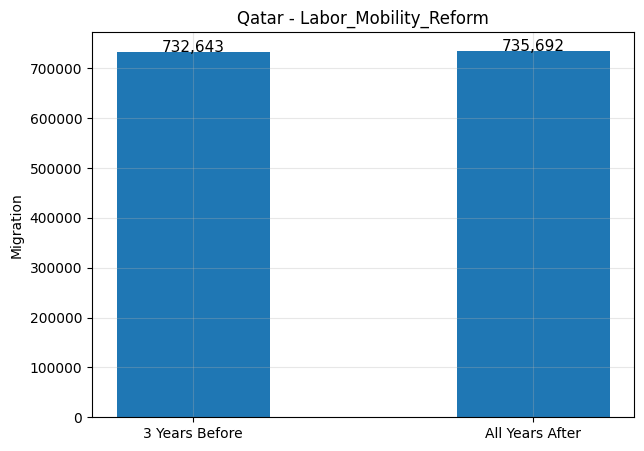


Variance Explained
[0.726  0.2004 0.0638]

PCA MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     278.5
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.55e-25
Time:                        14:36:59   Log-Likelihood:                -447.41
No. Observations:                  37   AIC:                             908.8
Df Residuals:                      30   BIC:                             920.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

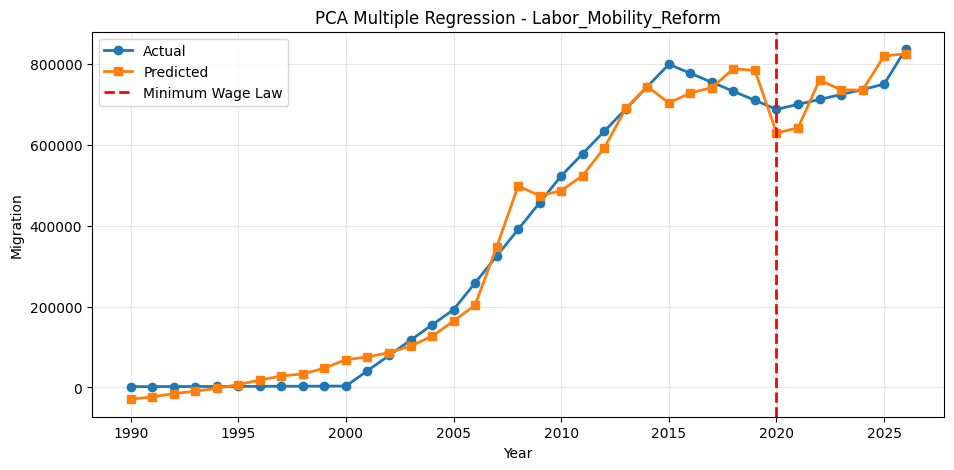


ENHANCED ITS
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     496.4
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.91e-28
Time:                        14:36:59   Log-Likelihood:                -446.22
No. Observations:                  37   AIC:                             910.4
Df Residuals:                      28   BIC:                             924.9
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      7.859e+04   1.71e

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


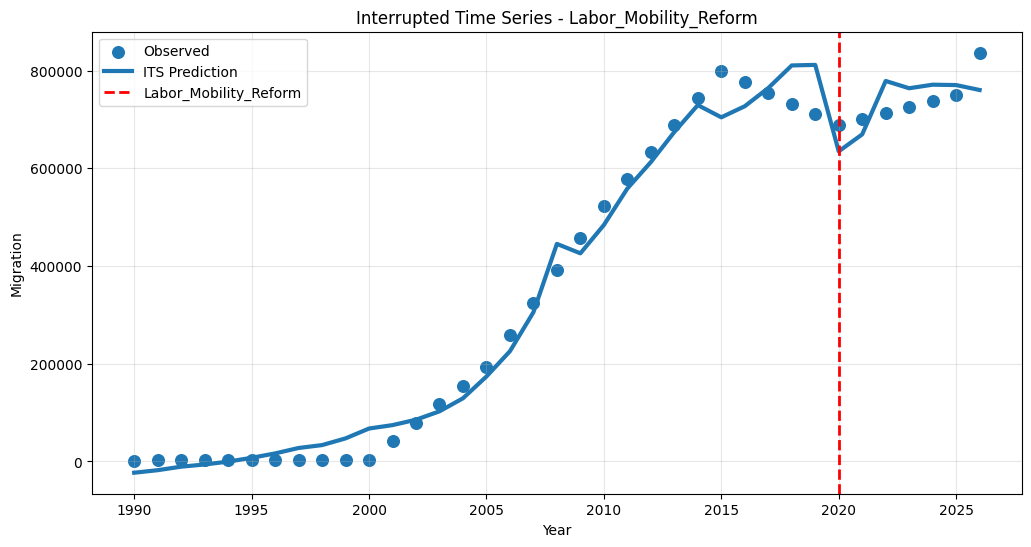

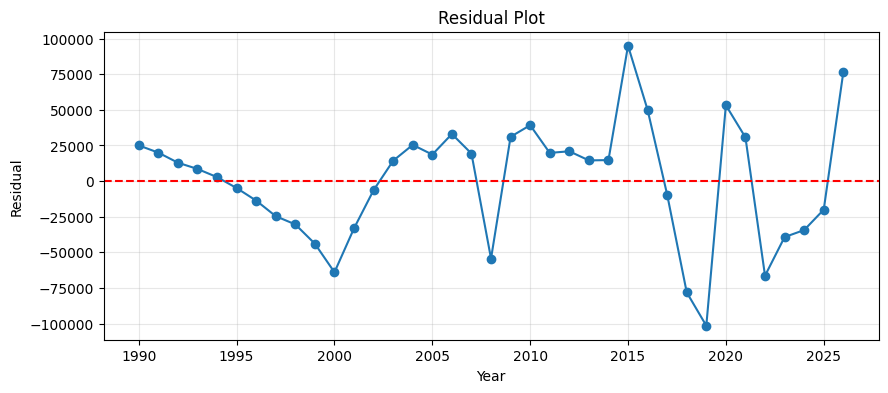


Durbin-Watson : 1.21


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

qatar = df[df["Country"]=="Qatar"].copy()

policy = "Labor_Mobility_Reform"

policy_year = qatar.loc[
    qatar[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :",policy)
print("Policy Year :",policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = qatar[
    (qatar["Year"]>=policy_year-3) &
    (qatar["Year"]<policy_year)
]

after = qatar[
    qatar["Year"]>=policy_year
]

before_median = before["Migration"].mean()
after_median = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("----------------------------")

print("Median Before :",round(before_median,2))
print("Median After  :",round(after_median,2))
print("Difference    :",round(after_median-before_median,2))

plt.figure(figsize=(7,5))

bars=plt.bar(
    ["3 Years Before","All Years After"],
    [before_median,after_median],
    width=.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Qatar - Labor_Mobility_Reform")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : PCA + MULTIPLE REGRESSION
# ======================================================

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

qatar["Year_Index"]=qatar["Year"]-qatar["Year"].min()

features=[

"Population",
"GDP",
"Inflation",
"Oil_Price",
"Exchange_Rate",
"Unemployment"

]

X=qatar[features]

X=X.fillna(X.median())

y=qatar["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(pca.explained_variance_ratio_,4))

pc_names=[]

for i in range(X_pca.shape[1]):
    pc_names.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=pc_names,
    index=qatar.index
)

reg_data=pd.concat(

[
pca_df,

qatar[[
"Migration",
"COVID",
"Year_Index",
"Minimum_Wage_Law"
]]

],

axis=1

)

formula="Migration ~ "

formula+=" + ".join(pc_names)

formula+=" + COVID + Year_Index + Minimum_Wage_Law"

model=smf.ols(

formula,

data=reg_data

).fit()

print("\nPCA MULTIPLE REGRESSION")

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nRegression Performance")

print("----------------------------")

print("R² :",round(

r2_score(
reg_data["Migration"],
reg_data["Prediction"]),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"])),2))

plt.figure(figsize=(11,5))

plt.plot(
qatar["Year"],
reg_data["Migration"],
marker='o',
linewidth=2,
label="Actual"
)

plt.plot(
qatar["Year"],
reg_data["Prediction"],
marker='s',
linewidth=2,
label="Predicted"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Minimum Wage Law"
)

plt.title("PCA Multiple Regression - Labor_Mobility_Reform")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 3 : ENHANCED INTERRUPTED TIME SERIES
# ======================================================

qatar=qatar.sort_values("Year").copy()

qatar["Time"]=qatar["Year"]-policy_year

qatar["Policy"]=(qatar["Year"]>=policy_year).astype(int)

qatar["Time_After"]=qatar["Time"].clip(lower=0)

qatar["Policy_Time"]=qatar["Policy"]*qatar["Time_After"]

qatar["COVID"]=(qatar["Year"]>=2020).astype(int)

its=smf.ols(

"""
Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=qatar

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("\nENHANCED ITS")

print(its.summary())

qatar["ITS_Prediction"]=its.predict(qatar)

print("\nITS Performance")

print("----------------------------")

print("R² :",round(

r2_score(

qatar["Migration"],
qatar["ITS_Prediction"]

),4))

print("RMSE :",round(

np.sqrt(

mean_squared_error(

qatar["Migration"],
qatar["ITS_Prediction"]

)),2))

plt.figure(figsize=(12,6))

plt.scatter(
qatar["Year"],
qatar["Migration"],
s=70,
label="Observed"
)

plt.plot(
qatar["Year"],
qatar["ITS_Prediction"],
linewidth=3,
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Labor_Mobility_Reform"
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Interrupted Time Series - Labor_Mobility_Reform")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 4 : RESIDUAL ANALYSIS
# ======================================================

qatar["Residuals"]=qatar["Migration"]-qatar["ITS_Prediction"]

plt.figure(figsize=(10,4))

plt.plot(
qatar["Year"],
qatar["Residuals"],
marker="o"
)

plt.axhline(
0,
color="red",
linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# STEP 5 : DURBIN-WATSON
# ======================================================

dw=durbin_watson(its.resid)

print("\nDurbin-Watson :",round(dw,3))